In [9]:
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import shap

In [10]:
def load_year(path, year):
    df = pd.read_excel(path, dtype=str) if path.endswith('.xlsx') else pd.read_csv(path, dtype=str)
    df['year'] = year
    return df

df = pd.concat([
    load_year("FoodAccessResearchAtlasData2010.xlsx", 2010),
    load_year("FoodAccessResearchAtlasData2015.xlsx", 2015),
    load_year("Food Access Research Atlas.csv", 2019)
], ignore_index=True)

print("Dataset shape:", df.shape)

Dataset shape: (72558, 149)


In [11]:
# NUMERIC CONVERSION
# ===========================
numeric_cols = [
    'PovertyRate','MedianFamilyIncome','lasnaphalfshare',
    'TractKids','TractSeniors',
    'TractWhite','TractBlack','TractHispanic',
    'HUNVFlag','Urban','Pop2010',
    'LowAccessPop','LowAccessPopNoVeh',
    'LowAccessPopUnder5','LowAccessPopOver65',
    'LandArea','Gini'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df['target'] = pd.to_numeric(df['LILATracts_1And10'], errors='coerce')
df = df.dropna(subset=['target'])

lasnaphalfshare       0.063246
MedianFamilyIncome    0.010681
TractKids             0.000427
TractHispanic         0.000427
TractSeniors          0.000427
TractWhite            0.000427
TractBlack            0.000427
PovertyRate           0.000413
HUNVFlag              0.000372
Urban                 0.000372
Pop2010               0.000372
dtype: float64


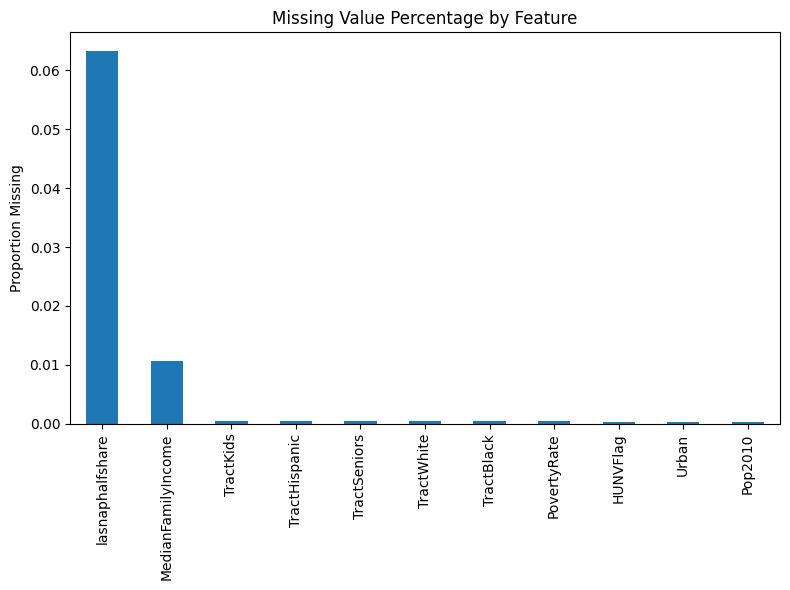

In [12]:
existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

missing_percent = (
    df[existing_numeric_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing_percent)

plt.figure(figsize=(8,6))
missing_percent.plot(kind='bar')
plt.title("Missing Value Percentage by Feature")
plt.ylabel("Proportion Missing")
plt.tight_layout()
plt.show()

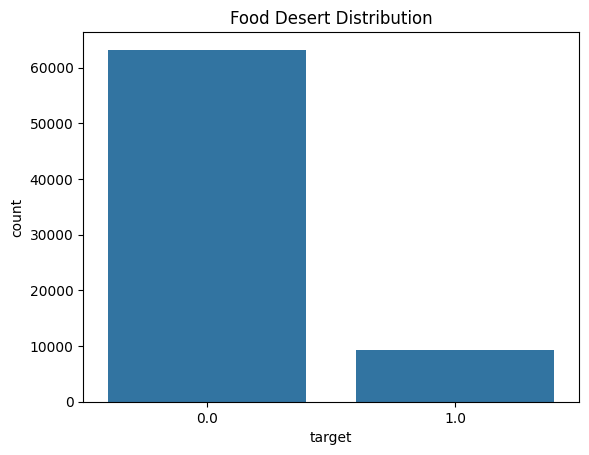

In [15]:
if 'target' not in df.columns:
    df['target'] = pd.to_numeric(df['LILATracts_1And10'], errors='coerce')
    df.dropna(subset=['target'], inplace=True)

sns.countplot(x='target', data=df)
plt.title("Food Desert Distribution")
plt.savefig("target_distribution.svg")
plt.show()

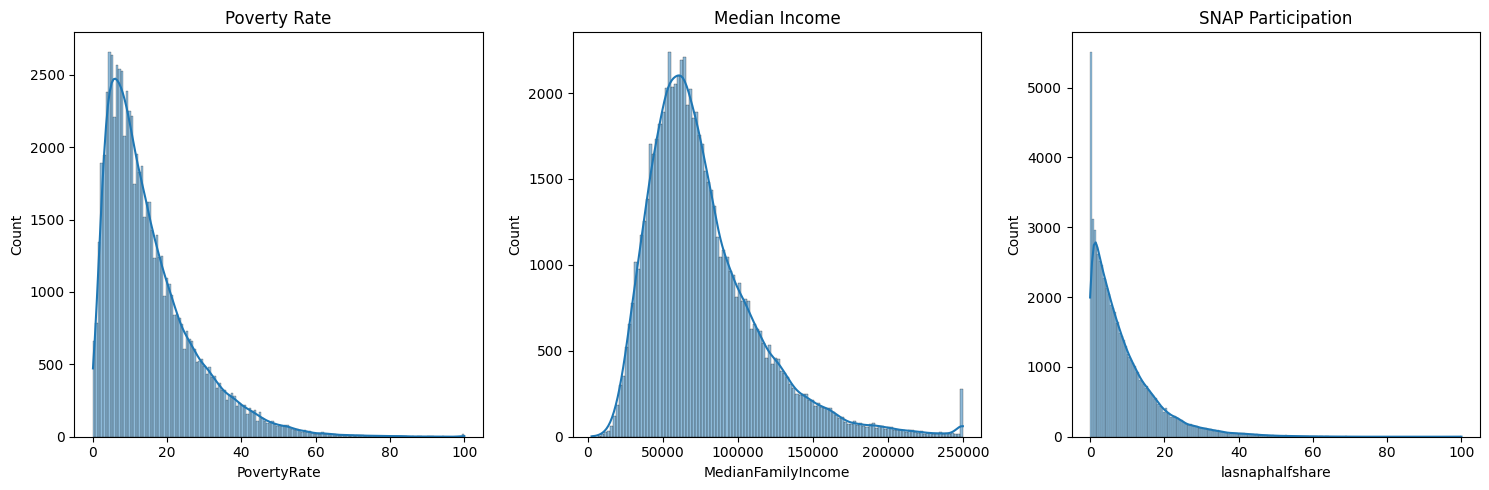

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.histplot(df['PovertyRate'], ax=axes[0], kde=True)
sns.histplot(df['MedianFamilyIncome'], ax=axes[1], kde=True)
sns.histplot(df['lasnaphalfshare'], ax=axes[2], kde=True)

axes[0].set_title("Poverty Rate")
axes[1].set_title("Median Income")
axes[2].set_title("SNAP Participation")

plt.tight_layout()
plt.savefig("distribution_plots.svg")
plt.show()

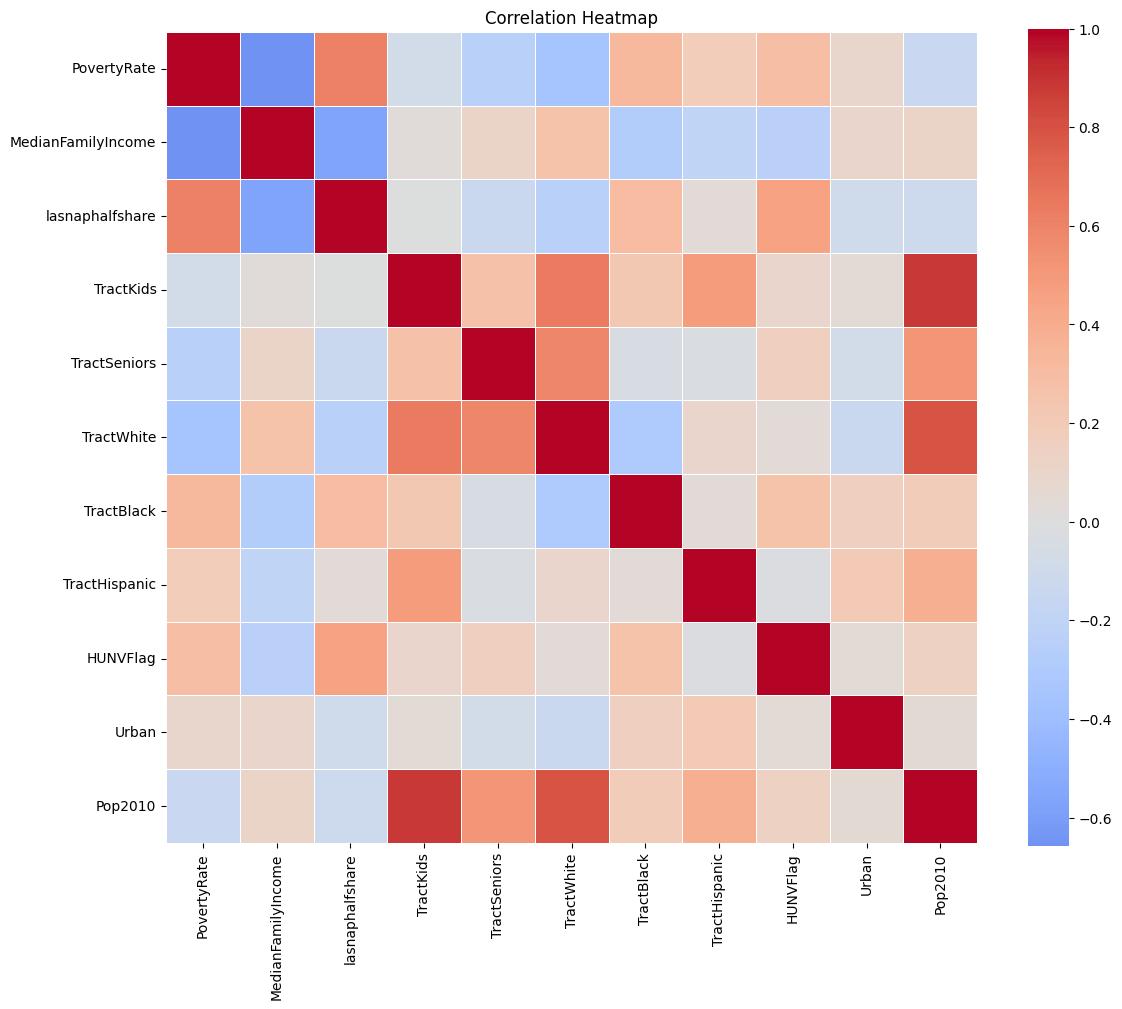

In [17]:
existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

numeric_df = df[existing_numeric_cols].select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [18]:
# 4. SELECT LITERATURE-ALIGNED FEATURES
# ==========================================

selected_features = [

    # Socioeconomic
    'PovertyRate',
    'MedianFamilyIncome',

    # Core low-access exposure shares
    'lapophalfshare',
    'lalowihalfshare',
    'lahunvhalfshare',
    'lasnaphalfshare',

    # Vulnerable population exposure
    'lakidshalfshare',
    'laseniorshalfshare',

    # Racial exposure within low-access
    'lablackhalfshare',
    'lahisphalfshare',

    # Controls
    'Urban',
    'HUNVFlag',
    'year'
]

# Convert to numeric safely
for col in selected_features:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=selected_features)

In [19]:
# 5. FEATURE ENGINEERING
# ==========================================

df['log_income'] = np.log1p(df['MedianFamilyIncome'])
df['poverty_vehicle_interaction'] = df['PovertyRate'] * df['HUNVFlag']

features = [
    'PovertyRate',
    'log_income',
    'lapophalfshare',
    'lalowihalfshare',
    'lahunvhalfshare',
    'lasnaphalfshare',
    'lakidshalfshare',
    'laseniorshalfshare',
    'lablackhalfshare',
    'lahisphalfshare',
    'Urban',
    'poverty_vehicle_interaction',

]


/tmp/ipykernel_149/2041871212.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_income'] = np.log1p(df['MedianFamilyIncome'])
/tmp/ipykernel_149/2041871212.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['poverty_vehicle_interaction'] = df['PovertyRate'] * df['HUNVFlag']


In [20]:
# 6. HANDLE MISSING VALUES
# ==========================================

imp = SimpleImputer(strategy='median')
X = pd.DataFrame(imp.fit_transform(df[features]), columns=features)
y = df['target']

In [21]:
# 7. TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [22]:
# 8. LOGISTIC REGRESSION
# ==========================================

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='roc_auc')

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("\nLogistic Regression")
print(classification_report(y_test, y_pred_lr))
print("CV ROC-AUC:", lr_scores.mean())


Logistic Regression
              precision    recall  f1-score   support

         0.0       0.97      0.83      0.89     11616
         1.0       0.43      0.82      0.56      1842

    accuracy                           0.82     13458
   macro avg       0.70      0.82      0.73     13458
weighted avg       0.89      0.82      0.85     13458

CV ROC-AUC: 0.9066406401908875


In [23]:
# 9. RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("CV ROC-AUC:", rf_scores.mean())


Random Forest
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94     11616
         1.0       0.62      0.74      0.67      1842

    accuracy                           0.90     13458
   macro avg       0.79      0.83      0.81     13458
weighted avg       0.91      0.90      0.91     13458

CV ROC-AUC: 0.9420545505367925


In [24]:
# 10. XGBOOST
# ==========================================

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost")
print(classification_report(y_test, y_pred_xgb))
print("CV ROC-AUC:", xgb_scores.mean())


XGBoost
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95     11616
         1.0       0.74      0.61      0.67      1842

    accuracy                           0.92     13458
   macro avg       0.84      0.79      0.81     13458
weighted avg       0.91      0.92      0.91     13458

CV ROC-AUC: 0.9446735812511804


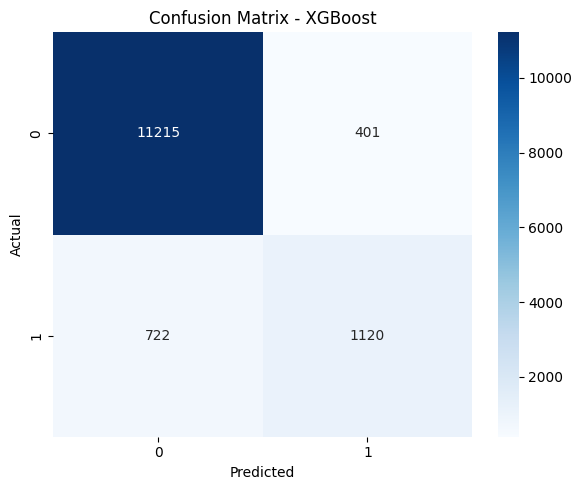

In [25]:
# 11. CONFUSION MATRIX (XGB)
# ==========================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

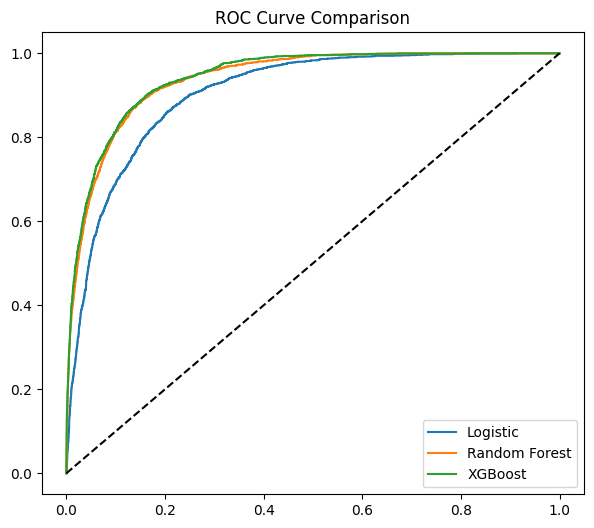

In [26]:
# 12. ROC CURVE COMPARISON
# ==========================================

plt.figure(figsize=(7,6))

for model, name in [
    (lr_pipeline, "Logistic"),
    (rf, "Random Forest"),
    (xgb_model, "XGBoost")
]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

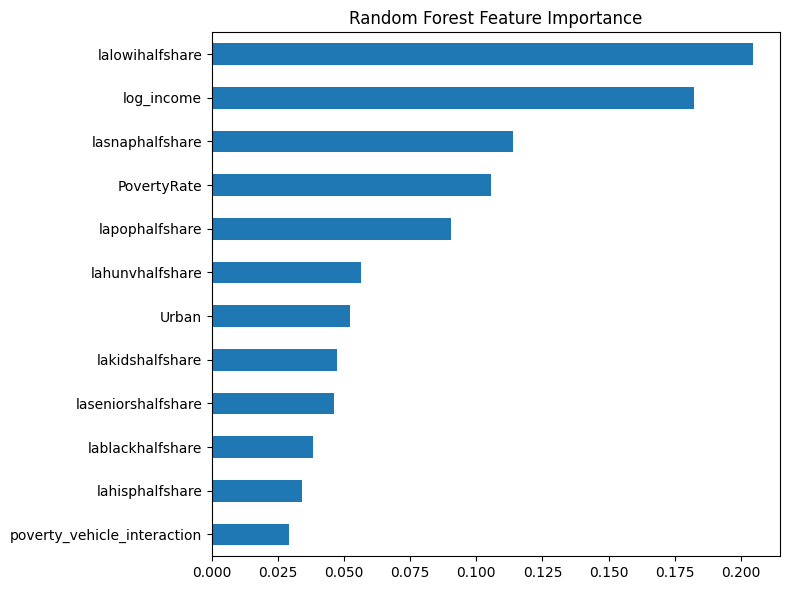

In [28]:
# 13. FEATURE IMPORTANCE (RF)
# ==========================================

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

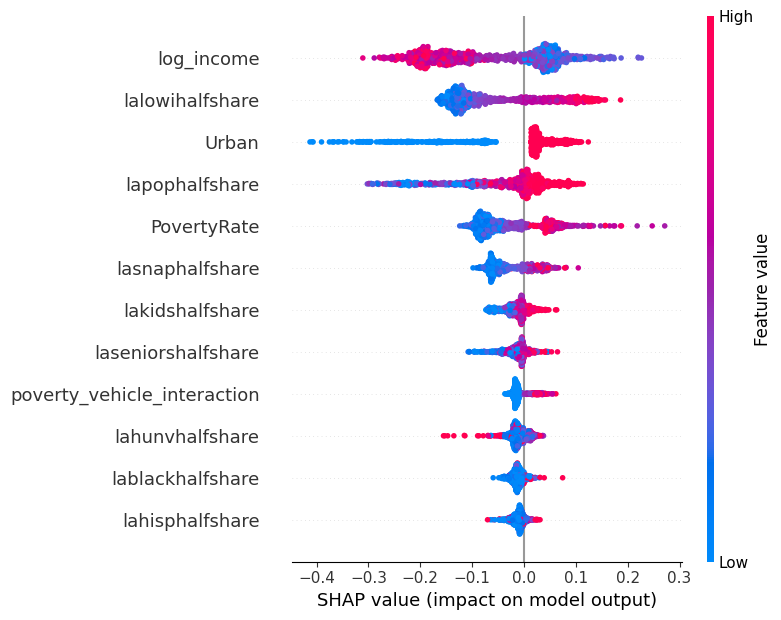

<Figure size 640x480 with 0 Axes>

In [31]:
# ==========================================
# 14. SHAP ANALYSIS (RF)
# ==========================================

explainer = shap.TreeExplainer(rf)
sample = X_test.sample(min(1000, len(X_test)), random_state=42)

shap_values = explainer.shap_values(sample)

# Correctly slice shap_values for class 1
shap.summary_plot(shap_values[:, :, 1], sample)
plt.savefig("shap_summary.svg")
plt.show()